In [3]:
import pandas as pd

# Load dataset
df = pd.read_csv(r"C:\Users\divya\OneDrive\Desktop\Machine Learning\demand_forecasting_bi\Walmart DataSet.csv")

print(df.head())
print(df.columns)

   Store        Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0      1  05-02-2010    1643690.90             0        42.31       2.572   
1      1  12-02-2010    1641957.44             1        38.51       2.548   
2      1  19-02-2010    1611968.17             0        39.93       2.514   
3      1  26-02-2010    1409727.59             0        46.63       2.561   
4      1  05-03-2010    1554806.68             0        46.50       2.625   

          CPI  Unemployment  
0  211.096358         8.106  
1  211.242170         8.106  
2  211.289143         8.106  
3  211.319643         8.106  
4  211.350143         8.106  
Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment'],
      dtype='object')


In [5]:
# Convert date
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

# Rename for consistency (Paper 1 style)
df.rename(columns={
    'Store': 'store_id',
    'Dept': 'product_id',
    'Weekly_Sales': 'units_sold',
    'IsHoliday': 'holiday'
}, inplace=True)

# Fill missing values
df.fillna(method='ffill', inplace=True)

print("Data cleaned")

Data cleaned


C:\Users\divya\AppData\Local\Temp\ipykernel_29184\1205200403.py:13: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [7]:
# Time features
df.rename(columns={
    'Store': 'store_id',
    'Dept': 'product_id',
    'Weekly_Sales': 'units_sold',
    'IsHoliday': 'holiday'
}, inplace=True)

print(df.columns.tolist())

['store_id', 'Date', 'units_sold', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'day', 'month', 'year', 'week', 'dayofweek']


In [9]:
print(df.columns.tolist())

['store_id', 'Date', 'units_sold', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'day', 'month', 'year', 'week', 'dayofweek']


In [10]:
# Rename only columns that actually exist
df.rename(columns={
    'Store': 'store_id',
    'Weekly_Sales': 'units_sold',
    'IsHoliday': 'holiday'
}, inplace=True)

# Sort by store and date
df = df.sort_values(['store_id', 'Date'])

# Lag features
df['lag_1'] = df.groupby('store_id')['units_sold'].shift(1)
df['lag_7'] = df.groupby('store_id')['units_sold'].shift(7)

# Rolling mean
df['rolling_mean_7'] = (
    df.groupby('store_id')['units_sold']
    .transform(lambda x: x.shift(1).rolling(7).mean())
)

# Remove rows with NaN created by lagging
df.dropna(inplace=True)

print(df.head())

    store_id       Date  units_sold  Holiday_Flag  Temperature  Fuel_Price  \
7          1 2010-03-26  1404429.92             0        51.45       2.732   
8          1 2010-04-02  1594968.28             0        62.27       2.719   
9          1 2010-04-09  1545418.53             0        65.86       2.770   
10         1 2010-04-16  1466058.28             0        66.32       2.808   
11         1 2010-04-23  1391256.12             0        64.84       2.795   

           CPI  Unemployment  day  month  year  week  dayofweek       lag_1  \
7   211.018042         8.106   26      3  2010    12          4  1472515.79   
8   210.820450         7.808    2      4  2010    13          4  1404429.92   
9   210.622857         7.808    9      4  2010    14          4  1594968.28   
10  210.488700         7.808   16      4  2010    15          4  1545418.53   
11  210.439123         7.808   23      4  2010    16          4  1466058.28   

         lag_7  rolling_mean_7  
7   1643690.90    1.539

In [11]:
df['inventory_level'] = df['units_sold'] * 2

In [13]:
df.columns = df.columns.str.strip()
df.rename(columns={'IsHoliday': 'holiday'}, inplace=True)

In [14]:
# Clean column names
df.columns = df.columns.str.strip()

# Create holiday column if not present
if 'IsHoliday' in df.columns:
    df.rename(columns={'IsHoliday': 'holiday'}, inplace=True)
elif 'holiday' not in df.columns:
    df['holiday'] = 0

In [15]:
features = [
    'Temperature', 'Fuel_Price', 'CPI', 'Unemployment',
    'holiday', 'inventory_level',
    'day', 'month', 'year', 'week', 'dayofweek',
    'lag_1', 'lag_7', 'rolling_mean_7'
]

X = df[features]
y = df['units_sold']

In [16]:
print(df.columns.tolist())

['store_id', 'Date', 'units_sold', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'day', 'month', 'year', 'week', 'dayofweek', 'lag_1', 'lag_7', 'rolling_mean_7', 'inventory_level', 'holiday']


In [20]:
from sklearn.model_selection import train_test_split

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [21]:
from sklearn.model_selection import train_test_split

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [22]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, y_train)

preds = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
rmse = mean_squared_error(y_test, preds) ** 0.5

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 269.88037532679897
RMSE: 604.5961487107036


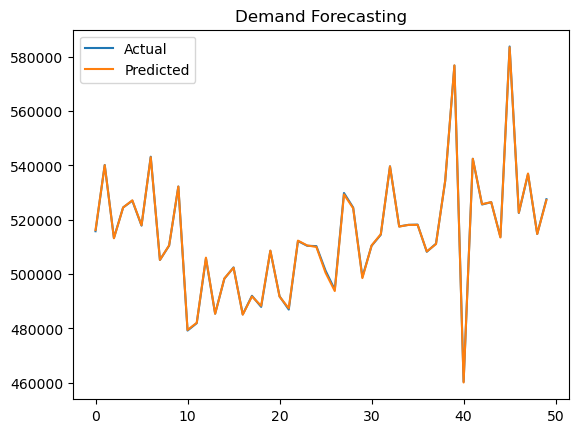

In [23]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(y_test.values[:50], label="Actual")
plt.plot(preds[:50], label="Predicted")
plt.legend()
plt.title("Demand Forecasting")
plt.show()

In [24]:
results = X_test.copy()
results['actual_sales'] = y_test.values
results['predicted_sales'] = preds
results['status'] = 'Pending'

print(results.head())

      Temperature  Fuel_Price         CPI  Unemployment  holiday  \
5155        55.76       2.732  209.787093         8.554        0   
5156        63.43       2.719  209.593866         8.464        0   
5157        68.54       2.770  209.400638         8.464        0   
5158        66.74       2.808  209.269143         8.464        0   
5159        68.03       2.795  209.219957         8.464        0   

      inventory_level  day  month  year  week  dayofweek      lag_1  \
5155       1031555.94   26      3  2010    12          4  460020.74   
5156       1080379.40    2      4  2010    13          4  515777.97   
5157       1026655.10    9      4  2010    14          4  540189.70   
5158       1049089.66   16      4  2010    15          4  513327.55   
5159       1054039.56   23      4  2010    16          4  524544.83   

          lag_7  rolling_mean_7  actual_sales  predicted_sales   status  
5155  536006.73   511735.645714     515777.97      516209.6393  Pending  
5156  529852.70 

In [25]:
def apply_rule(row):
    if row['predicted_sales'] < 0:
        return row['lag_1']
    return row['predicted_sales']

results['final_forecast'] = results.apply(apply_rule, axis=1)

In [26]:
results.to_csv("forecast_results.csv", index=False)

In [27]:
results = X_test.copy()
results['actual_sales'] = y_test.values
results['predicted_sales'] = preds

In [29]:
results['store_id'] = df.loc[X_test.index, 'store_id'].values
results['Date'] = df.loc[X_test.index, 'Date'].values
results['lag_1'] = df.loc[X_test.index, 'lag_1'].values
results['holiday'] = df.loc[X_test.index, 'holiday'].values

In [30]:
def apply_rule_engine(row):
    pred = row['predicted_sales']

    # Rule 1: no negative forecast
    if pred < 0:
        return row['lag_1']

    # Rule 2: if prediction is too low on holiday, slightly increase it
    if row['holiday'] == 1 and pred < row['lag_1']:
        return row['lag_1'] * 1.10

    # Rule 3: if prediction is unrealistically huge, cap it
    if pred > row['lag_1'] * 2:
        return row['lag_1'] * 1.5

    return pred

In [31]:
results['final_forecast'] = results.apply(apply_rule_engine, axis=1)
print(results[['store_id', 'Date', 'actual_sales', 'predicted_sales', 'final_forecast']].head())

      store_id       Date  actual_sales  predicted_sales  final_forecast
5155        37 2010-03-26     515777.97      516209.6393     516209.6393
5156        37 2010-04-02     540189.70      540109.6752     540109.6752
5157        37 2010-04-09     513327.55      513184.1744     513184.1744
5158        37 2010-04-16     524544.83      524519.9944     524519.9944
5159        37 2010-04-23     527019.78      527165.6104     527165.6104


In [32]:
store_counts = df.groupby('store_id').size().to_dict()
results['history_count'] = results['store_id'].map(store_counts)

In [33]:
def apply_rule_engine(row):
    pred = row['predicted_sales']

    if row['history_count'] < 10:
        return row['lag_1']

    if pred < 0:
        return row['lag_1']

    if row['holiday'] == 1 and pred < row['lag_1']:
        return row['lag_1'] * 1.10

    if pred > row['lag_1'] * 2:
        return row['lag_1'] * 1.5

    return pred

In [34]:
results.to_csv("forecast_results.csv", index=False)